In [2]:
#libraries in medical imaging
!pip install pydicom

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 24.9 MB/s eta 0:00:00


In [3]:
#loads the DICOM library into Python
import pydicom
#plotting library
import matplotlib.pyplot as plt
#Numpy is the numerical library in Python and stores the CT image numbers
import numpy as np

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
#find thd dataset path
import os

os.listdir("/content/drive/MyDrive")

['Coronary Disease.gdoc',
 'Software_Operation_Manual_SMM-MAE-zh-CN-translation.gdoc',
 'Software Operation Manual.gdoc',
 'ECG Label.gsheet',
 'Heart disease data.gdoc',
 '无标题文档.gdoc',
 'ECG label.gdoc',
 'Binary for heart disease.ipynb',
 '心脏CT_Biomedical_AI项目.gdoc',
 'CT ai.gdoc',
 'AI_Medical',
 'Colab Notebooks',
 'Untitled1.ipynb']

In [6]:
#get into the AI medical file
os.listdir("/content/drive/MyDrive/AI_Medical")

['COCA']

In [7]:
os.listdir("/content/drive/MyDrive/AI_Medical/COCA/raw_data")

['gated_files']

In [8]:
patient_path = "/content/drive/MyDrive/AI_Medical/COCA/raw_data/gated_files/patient"

import os

print(os.listdir(patient_path)[:10])

['.DS_Store', '135', '307', '763', '551', '61', '95', '338', '556', '764']


In [9]:
#Ignore DS_store
patients = [
    p for p in os.listdir(patient_path) #Show everthing inside the folder
    if not p.startswith(".") #Ignore anything beginning with .(like.DS_store)
]

print(patients[:10])

['135', '307', '763', '551', '61', '95', '338', '556', '764', '300']


In [10]:
patients = [
    p for p in os.listdir(patient_path) #Take one item at a time
    if not p.startswith(".") #Ignore anything beginning with .(like.DS_store)
]

first_patient = patients[0] #First Patient

print(first_patient)

135


In [11]:
dicom_folder = os.path.join(patient_path, first_patient)

print(os.listdir(dicom_folder)[:10])

['Pro_Gated_Calcium_Score_(CS)_3.0_Qr36_2_BestDiast_70_%']


In [12]:
# Create a new varible which store the path to the folder that contains all the DICOM images
scan_folder = os.path.join(
    dicom_folder,
    os.listdir(dicom_folder)[0]#return the first folder
)

print(scan_folder)

/content/drive/MyDrive/AI_Medical/COCA/raw_data/gated_files/patient/135/Pro_Gated_Calcium_Score_(CS)_3.0_Qr36_2_BestDiast_70_%


In [13]:
print(os.listdir(scan_folder)[:10])

['.azDownload-106f050f-1fc2-8547-7741-7bce76d6180a-IM-3678-0024.dcm', 'IM-3678-0044.dcm', 'IM-3678-0016.dcm', 'IM-3678-0008.dcm', 'IM-3678-0032.dcm', 'IM-3678-0003.dcm', 'IM-3678-0022.dcm', 'IM-3678-0011.dcm', 'IM-3678-0005.dcm', 'IM-3678-0017.dcm']


In [14]:
#Keep only files ending with dcm
dicom_files = [
    f for f in os.listdir(scan_folder) # Go through every file
    if f.endswith(".dcm") and not f.startswith(".") # Keep only files ending with.dcm, ignore hidden file
]

print(dicom_files[:10])

['IM-3678-0044.dcm', 'IM-3678-0016.dcm', 'IM-3678-0008.dcm', 'IM-3678-0032.dcm', 'IM-3678-0003.dcm', 'IM-3678-0022.dcm', 'IM-3678-0011.dcm', 'IM-3678-0005.dcm', 'IM-3678-0017.dcm', 'IM-3678-0033.dcm']


In [15]:
print(dicom_files[:20])

['IM-3678-0044.dcm', 'IM-3678-0016.dcm', 'IM-3678-0008.dcm', 'IM-3678-0032.dcm', 'IM-3678-0003.dcm', 'IM-3678-0022.dcm', 'IM-3678-0011.dcm', 'IM-3678-0005.dcm', 'IM-3678-0017.dcm', 'IM-3678-0033.dcm', 'IM-3678-0001.dcm', 'IM-3678-0041.dcm', 'IM-3678-0028.dcm', 'IM-3678-0021.dcm', 'IM-3678-0046.dcm', 'IM-3678-0034.dcm', 'IM-3678-0012.dcm', 'IM-3678-0009.dcm', 'IM-3678-0039.dcm', 'IM-3678-0006.dcm']


In [16]:
#Find one DICOM file
first_dicom = os.path.join(
    scan_folder,
    dicom_files[0]
)

print(first_dicom)

/content/drive/MyDrive/AI_Medical/COCA/raw_data/gated_files/patient/135/Pro_Gated_Calcium_Score_(CS)_3.0_Qr36_2_BestDiast_70_%/IM-3678-0044.dcm


In [17]:
# prints everything stored inside one DICOM file (patient, Scanner, Geometry, Acquisition, Image, Pixel data)
import pydicom

ds = pydicom.dcmread(first_dicom)
print(ds)

/usr/local/lib/python3.12/dist-packages/pydicom/valuerep.py:440: UserWarning: Invalid value for VR UI: '2.47640079549721136553.81403395.07777395709537039373885678825733'. Please see <https://dicom.nema.org/medical/dicom/current/output/html/part05.html#table_6.2-1> for allowed values for each VR.
  warn_and_log(msg)
/usr/local/lib/python3.12/dist-packages/pydicom/valuerep.py:440: UserWarning: Invalid value for VR UI: '3.73179259012192234270.20046790.09831994490516846060680507367277'. Please see <https://dicom.nema.org/medical/dicom/current/output/html/part05.html#table_6.2-1> for allowed values for each VR.
  warn_and_log(msg)
/usr/local/lib/python3.12/dist-packages/pydicom/valuerep.py:440: UserWarning: Invalid value for VR UI: '9.00520776813234670151.67292198.35951145737311013077293650973488'. Please see <https://dicom.nema.org/medical/dicom/current/output/html/part05.html#table_6.2-1> for allowed values for each VR.
  warn_and_log(msg)


Dataset.file_meta -------------------------------
(0002,0000) File Meta Information Group Length  UL: 216
(0002,0001) File Meta Information Version       OB: b'\x00\x01'
(0002,0002) Media Storage SOP Class UID         UI: CT Image Storage
(0002,0003) Media Storage SOP Instance UID      UI: 2.20201215184154992112.10000012.69859053445329151922406636455287
(0002,0010) Transfer Syntax UID                 UI: Explicit VR Little Endian
(0002,0012) Implementation Class UID            UI: 1.2.276.0.7230010.3.0.3.6.1
(0002,0013) Implementation Version Name         SH: 'OSIRIX_361'
(0002,0017) Sending Application Entity Title    AE: 'SHC_QR'
-------------------------------------------------
(0008,0005) Specific Character Set              CS: 'ISO_IR 100'
(0008,0008) Image Type                          CS: ['ORIGINAL', 'PRIMARY', 'AXIAL', 'CT_SOM5 SEQ DUAL', 'STD', 'SNRG', 'DET_AB']
(0008,0016) SOP Class UID                       UI: CT Image Storage
(0008,0018) SOP Instance UID                  

/usr/local/lib/python3.12/dist-packages/pydicom/valuerep.py:440: UserWarning: Invalid value for VR UI: '6.95103509928090893554.08547098.05794043220407171973819358964837'. Please see <https://dicom.nema.org/medical/dicom/current/output/html/part05.html#table_6.2-1> for allowed values for each VR.
  warn_and_log(msg)


In [18]:
# Give me the image stored inside the DICOM and only extract CT image
image = ds.pixel_array
print(type(image))
# How many rows and columns the image has
print(image.shape)
print(image.dtype)

<class 'numpy.ndarray'>
(512, 512)
uint16


In [56]:
import os

os.makedirs("/content/drive/MyDrive/AI_Medical/COCA/figures", exist_ok=True)

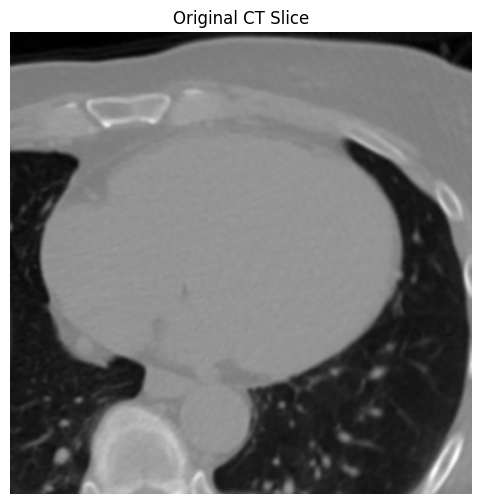

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
#Display an image with color gray
plt.imshow(image, cmap="gray")
plt.title("Original CT Slice")
plt.axis("off")
plt.savefig(
    "/content/drive/MyDrive/AI_Medical/COCA/figures/original_ct.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [20]:
#Convert pixels into HU, HU=pixel*1+intercept
slope = float(ds.RescaleSlope)
intercept = float(ds.RescaleIntercept)

print("RescaleSlope:", slope)
print("RescaleIntercept:", intercept)

RescaleSlope: 1.0
RescaleIntercept: -1024.0


In [21]:
image_hu = image.astype(np.float32) * slope + intercept

print("Minimum HU:", image_hu.min())
print("Maximum HU:", image_hu.max())
print("Mean HU:", image_hu.mean())

Minimum HU: -1024.0
Maximum HU: 1082.0
Mean HU: -62.96051


In [22]:
# To set the windowing function (shrink the range)
def apply_window(image_hu, window_center, window_width):
    """
    Apply CT windowing.
    """

    lower = window_center - window_width / 2
    upper = window_center + window_width / 2
#Everything outside the window is clipped to the neareast boundary
    windowed = np.clip(image_hu, lower, upper)

    return windowed

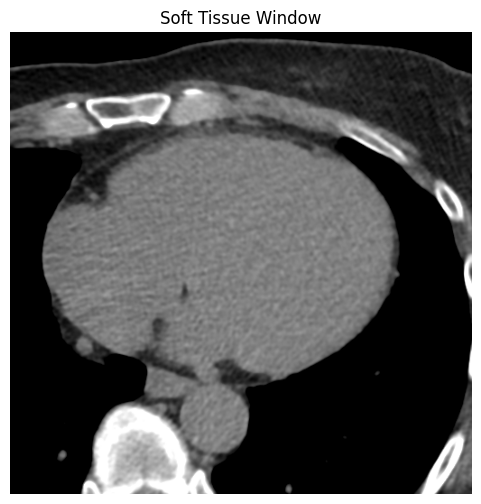

In [58]:
# Show the soft tissue window
windowed_image = apply_window(
    image_hu,
    window_center=40,
    window_width=400
)

plt.figure(figsize=(6,6))
plt.imshow(windowed_image, cmap="gray")
plt.title("Soft Tissue Window")
plt.axis("off")
plt.savefig(
    "/content/drive/MyDrive/AI_Medical/COCA/figures/Soft_Tissue_Window.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [24]:
#After clipped, the original hu do not change
print(image_hu.min())
print(image_hu.max())

-1024.0
1082.0


In [25]:
#To get the XML folder path
xml_path = "/content/drive/MyDrive/AI_Medical/COCA/raw_data/gated_files/calcium_xml"

In [26]:
#Ignore hidden files and list XML files
xml_files = [
    f for f in os.listdir(xml_path)
    if f.endswith(".xml") and not f.startswith(".")
]

print("Number of XML files:", len(xml_files))
print(xml_files[:10])

Number of XML files: 451
['152.xml', '396.xml', '302.xml', '297.xml', '327.xml', '179.xml', '103.xml', '429.xml', '307.xml', '105.xml']


In [27]:
# Check if xml file match with dcm
print("Current patient folder:", first_patient)
print("First 20 XML files:", xml_files[:20])

Current patient folder: 135
First 20 XML files: ['152.xml', '396.xml', '302.xml', '297.xml', '327.xml', '179.xml', '103.xml', '429.xml', '307.xml', '105.xml', '0.xml', '86.xml', '153.xml', '273.xml', '111.xml', '68.xml', '384.xml', '84.xml', '236.xml', '411.xml']


In [28]:
expected_xml = f"{first_patient}.xml"

print("Expected XML:", expected_xml)
print("Does it exist?", expected_xml in xml_files)

Expected XML: 135.xml
Does it exist? True


In [29]:
patient_xml = os.path.join(xml_path, expected_xml)
print(patient_xml)

/content/drive/MyDrive/AI_Medical/COCA/raw_data/gated_files/calcium_xml/135.xml


In [30]:
#Open the XML file and read it,tell Python how to interpret the text, prevent unusual characters from stopping the code
with open(patient_xml, "r", encoding="utf-8", errors="ignore") as file:
    xml_text = file.read()

print(xml_text[:4000])

<?xml version="1.0" encoding="UTF-8"?>
<!DOCTYPE plist PUBLIC "-//Apple//DTD PLIST 1.0//EN" "http://www.apple.com/DTDs/PropertyList-1.0.dtd">
<plist version="1.0">
<dict>
	<key>Images</key>
	<array>
		<dict>
			<key>ImageIndex</key>
			<integer>12</integer>
			<key>NumberOfROIs</key>
			<integer>1</integer>
			<key>ROIs</key>
			<array>
				<dict>
					<key>Area</key>
					<real>0.0</real>
					<key>Center</key>
					<string>(-36.500000, -263.500000, -200.500000)</string>
					<key>Dev</key>
					<real>0.0</real>
					<key>IndexInImage</key>
					<integer>0</integer>
					<key>Length</key>
					<real>0.0</real>
					<key>Max</key>
					<real>0.0</real>
					<key>Mean</key>
					<real>0.0</real>
					<key>Min</key>
					<real>0.0</real>
					<key>Name</key>
					<string>Left Circumflex Artery</string>
					<key>NumberOfPoints</key>
					<integer>0</integer>
					<key>Point_mm</key>
					<array/>
					<key>Point_px</key>
					<array/>
					<key>Total</key>
					<real>0.0</real>
					<key

In [31]:
# Does this exact word apper anywhere in the XML
keywords = [
    "Point",
    "Contour",
    "Polygon",
    "Vertices",
    "Vertex",
    "Pixel",
    "Path",
    "Coordinate",
    "Coordinates"
]

for word in keywords:
    print(word, word in xml_text)

Point True
Contour False
Polygon False
Vertices False
Vertex False
Pixel False
Path False
Coordinate False
Coordinates False


In [32]:
#Tells the location of calcium
for word in keywords:
    position = xml_text.find(word)

    if position != -1:
        print("\nFOUND:", word)
        print(xml_text[position - 300: position + 1000])


FOUND: Point
ndexInImage</key>
					<integer>0</integer>
					<key>Length</key>
					<real>0.0</real>
					<key>Max</key>
					<real>0.0</real>
					<key>Mean</key>
					<real>0.0</real>
					<key>Min</key>
					<real>0.0</real>
					<key>Name</key>
					<string>Left Circumflex Artery</string>
					<key>NumberOfPoints</key>
					<integer>0</integer>
					<key>Point_mm</key>
					<array/>
					<key>Point_px</key>
					<array/>
					<key>Total</key>
					<real>0.0</real>
					<key>Type</key>
					<integer>20</integer>
				</dict>
			</array>
		</dict>
		<dict>
			<key>ImageIndex</key>
			<integer>29</integer>
			<key>NumberOfROIs</key>
			<integer>1</integer>
			<key>ROIs</key>
			<array>
				<dict>
					<key>Area</key>
					<real>0.0023365020751953125</real>
					<key>Center</key>
					<string>(49.291016, -164.891602, -149.500000)</string>
					<key>Dev</key>
					<real>4.242640495300293</real>
					<key>IndexInImage</key>
					<integer>0</integer>
					<key>Length</key>
					<real>0.2

In [33]:
# To search the XML for real calcium lesions
import re

# Find every NumberOfPoints value
matches = re.findall(
    r"<key>NumberOfPoints</key>\s*<integer>(\d+)</integer>",
    xml_text
)

numbers = [int(x) for x in matches]

print("Total ROIs:", len(numbers))
print("Maximum NumberOfPoints:", max(numbers))
print("ROIs with points:", sum(n > 0 for n in numbers))

Total ROIs: 19
Maximum NumberOfPoints: 16
ROIs with points: 3


In [34]:
import plistlib

with open(patient_xml, "rb") as f:
    annotation = plistlib.load(f)

print(type(annotation))
print(annotation.keys())

<class 'dict'>
dict_keys(['Images'])


In [35]:
images_info = annotation["Images"]

print("Number of annotated image entries:", len(images_info))
print(images_info[0].keys())

Number of annotated image entries: 4
dict_keys(['ImageIndex', 'NumberOfROIs', 'ROIs'])


In [36]:
real_rois = []

for image_entry in images_info:
    image_index = image_entry["ImageIndex"]

    for roi in image_entry.get("ROIs", []):
        number_of_points = roi.get("NumberOfPoints", 0)

        if number_of_points > 0:
            real_rois.append({
                "image_index": image_index,
                "name": roi.get("Name", "Unknown"),
                "number_of_points": number_of_points,
                "points_px": roi.get("Point_px", []),
                "area": roi.get("Area", None)
            })

print("Real ROIs found:", len(real_rois))

for roi in real_rois:
    print(roi)

Real ROIs found: 3
{'image_index': 29, 'name': 'Left Circumflex Artery', 'number_of_points': 6, 'points_px': ['(250.003922, 288.000000)', '(250.003922, 289.000000)', '(251.000000, 289.996078)', '(251.996078, 289.000000)', '(251.996078, 288.000000)', '(251.000000, 287.003922)'], 'area': 0.0023365020751953125}
{'image_index': 30, 'name': 'Left Anterior Descending Artery', 'number_of_points': 16, 'points_px': ['(261.003922, 258.000000)', '(261.000000, 258.003922)', '(260.000000, 258.003922)', '(259.003922, 259.000000)', '(259.000000, 259.003922)', '(258.003922, 260.000000)', '(259.000000, 260.996078)', '(260.000000, 260.996078)', '(260.996078, 260.000000)', '(261.000000, 259.996078)', '(262.000000, 259.996078)', '(262.996078, 259.000000)', '(263.000000, 258.996078)', '(263.996078, 258.000000)', '(263.000000, 257.003922)', '(262.000000, 257.003922)'], 'area': 0.008177757263183594}
{'image_index': 30, 'name': 'Left Circumflex Artery', 'number_of_points': 8, 'points_px': ['(249.003922, 287.0

In [37]:
first_real_roi = real_rois[0]

print("Image index:", first_real_roi["image_index"])
print("Artery:", first_real_roi["name"])
print("Number of points:", first_real_roi["number_of_points"])
print("Area:", first_real_roi["area"])
print("Pixel points:")
print(first_real_roi["points_px"])

Image index: 29
Artery: Left Circumflex Artery
Number of points: 6
Area: 0.0023365020751953125
Pixel points:
['(250.003922, 288.000000)', '(250.003922, 289.000000)', '(251.000000, 289.996078)', '(251.996078, 289.000000)', '(251.996078, 288.000000)', '(251.000000, 287.003922)']


In [38]:
# Find index 29
dicom_files = sorted(
    [f for f in os.listdir(scan_folder)
     if f.endswith(".dcm") and not f.startswith(".")]
)

print("Number of DICOM files:", len(dicom_files))
print("First 5:", dicom_files[:5])
print("Slice 29 filename:", dicom_files[29])

Number of DICOM files: 46
First 5: ['IM-3678-0001.dcm', 'IM-3678-0002.dcm', 'IM-3678-0003.dcm', 'IM-3678-0004.dcm', 'IM-3678-0005.dcm']
Slice 29 filename: IM-3678-0030.dcm


In [39]:
# Read slice 29
slice29_path = os.path.join(scan_folder, dicom_files[29])

ds29 = pydicom.dcmread(slice29_path, force=True)

print(ds29.InstanceNumber)
print(ds29.SOPInstanceUID)

30
4.40704102324757630534.51002461.00237069717658430229584579619339


/usr/local/lib/python3.12/dist-packages/pydicom/valuerep.py:440: UserWarning: Invalid value for VR UI: '4.40704102324757630534.51002461.00237069717658430229584579619339'. Please see <https://dicom.nema.org/medical/dicom/current/output/html/part05.html#table_6.2-1> for allowed values for each VR.
  warn_and_log(msg)


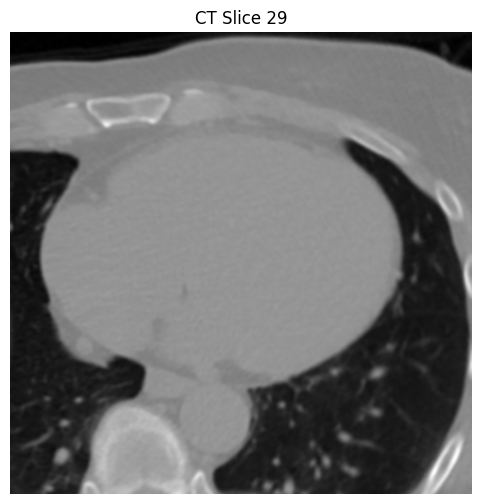

In [40]:
image29 = ds29.pixel_array

plt.figure(figsize=(6,6))
plt.imshow(image29, cmap="gray")
plt.title("CT Slice 29")
plt.axis("off")
plt.show()

In [41]:
annotated_index = first_real_roi["image_index"]

# Sort DICOM files by InstanceNumber
sorted_dicoms = []

for filename in dicom_files:
    path = os.path.join(scan_folder, filename)
    temp_ds = pydicom.dcmread(path, stop_before_pixels=True)

    sorted_dicoms.append(
        (int(temp_ds.InstanceNumber), filename)
    )

sorted_dicoms.sort(key=lambda item: item[0])

selected_instance, selected_filename = sorted_dicoms[annotated_index]

print("XML ImageIndex:", annotated_index)
print("Selected filename:", selected_filename)
print("DICOM InstanceNumber:", selected_instance)

XML ImageIndex: 29
Selected filename: IM-3678-0030.dcm
DICOM InstanceNumber: 30


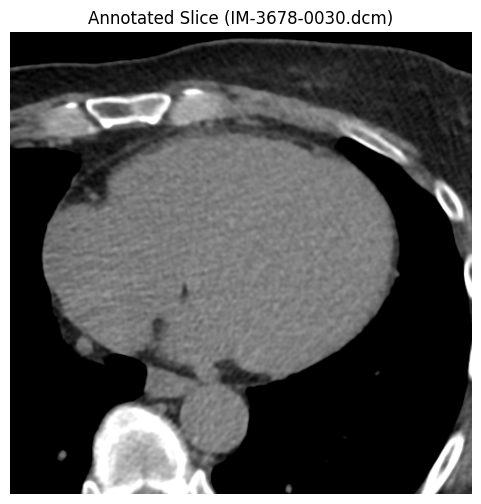

In [42]:
#Load the annotated slice
annotated_path = os.path.join(scan_folder, selected_filename)

ds = pydicom.dcmread(annotated_path)

image = ds.pixel_array.astype(np.float32)

image_hu = (
    image * float(ds.RescaleSlope)
    + float(ds.RescaleIntercept)
)

windowed = apply_window(
    image_hu,
    window_center=40,
    window_width=400
)

plt.figure(figsize=(6,6))
plt.imshow(windowed, cmap="gray")
plt.title(f"Annotated Slice ({selected_filename})")
plt.axis("off")
plt.show()

In [43]:
import re
import numpy as np
from matplotlib.patches import Polygon

# Convert "(250.0, 288.0)" -> [250.0, 288.0]
points = []

for p in first_real_roi["points_px"]:
    nums = re.findall(r"-?\d+\.?\d*", p)
    points.append([float(nums[0]), float(nums[1])])

points = np.array(points)

print(points)

[[250.003922 288.      ]
 [250.003922 289.      ]
 [251.       289.996078]
 [251.996078 289.      ]
 [251.996078 288.      ]
 [251.       287.003922]]


In [44]:
print("Number of points:", len(points))
print(points)

print("Shape:", points.shape)

Number of points: 6
[[250.003922 288.      ]
 [250.003922 289.      ]
 [251.       289.996078]
 [251.996078 289.      ]
 [251.996078 288.      ]
 [251.       287.003922]]
Shape: (6, 2)


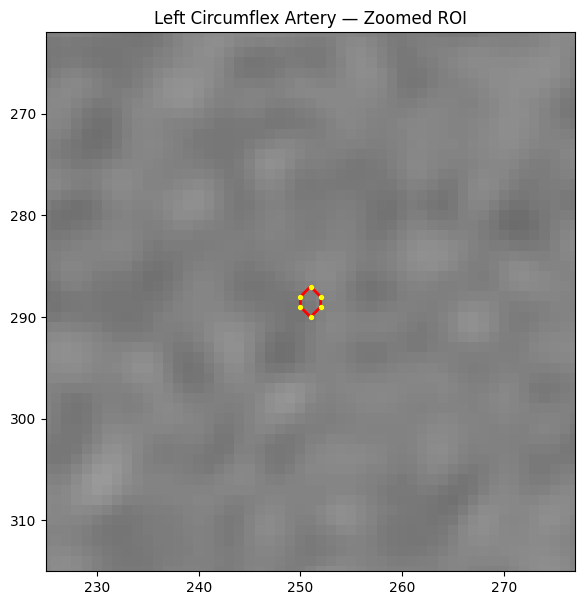

In [59]:
# Zoom out the ROI
fig, ax = plt.subplots(figsize=(7, 7))

ax.imshow(windowed, cmap="gray")

polygon = Polygon(
    points,
    closed=True,
    fill=False,
    edgecolor="red",
    linewidth=2
)

ax.add_patch(polygon)

ax.scatter(
    points[:, 0],
    points[:, 1],
    c="yellow",
    s=8
)

# Zoom around the calcium ROI
margin = 25

ax.set_xlim(
    points[:, 0].min() - margin,
    points[:, 0].max() + margin
)

ax.set_ylim(
    points[:, 1].max() + margin,
    points[:, 1].min() - margin
)

ax.set_title(
    f"{first_real_roi['name']} — Zoomed ROI"
)

plt.savefig(
    "/content/drive/MyDrive/AI_Medical/COCA/figures/Zoomed_Calcium_Polygon.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

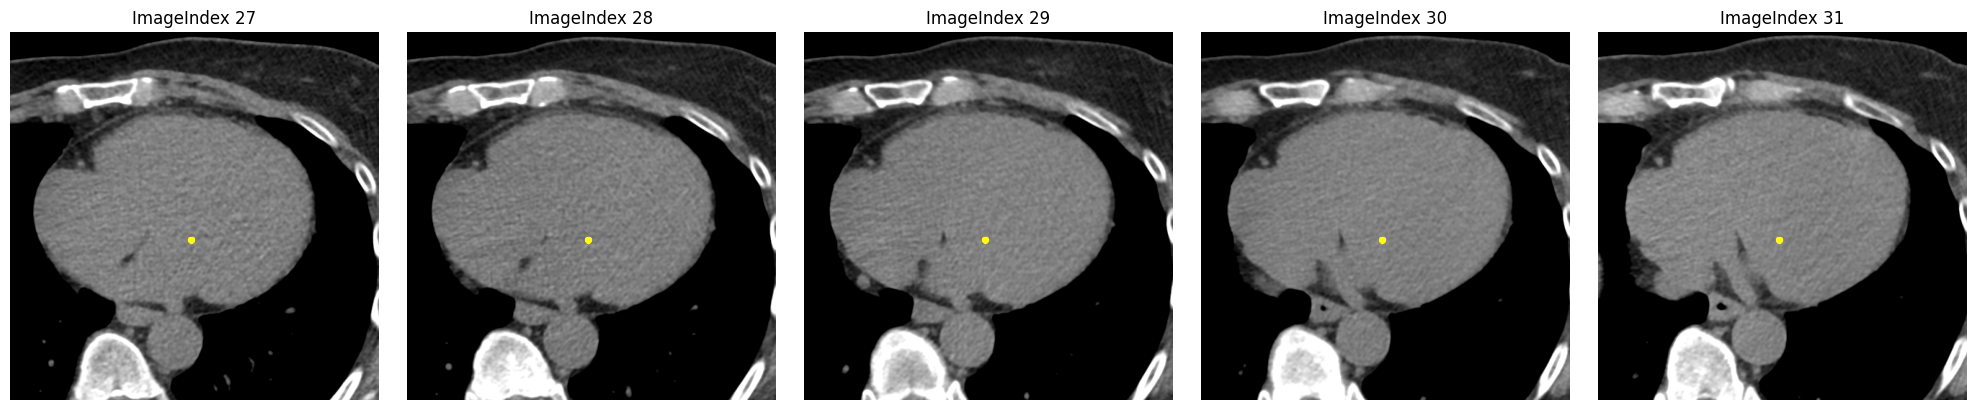

In [47]:
# Verify the slice mapping (test other slices )
#Create one figure containing 5 plots arranged in 1 row*5columns
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
# To draw the image for slices 27-31
for i, offset in enumerate([-2, -1, 0, 1, 2]):
    idx = annotated_index + offset

    instance, filename = sorted_dicoms[idx]
# Load the CT slice which contains metadata, pixel array...
    ds_temp = pydicom.dcmread(
        os.path.join(scan_folder, filename)
    )
#Extract only the image
    img = ds_temp.pixel_array.astype(np.float32)
#Convert pixels into HU
    img = img * float(ds_temp.RescaleSlope) + float(ds_temp.RescaleIntercept)
# Set the windowing function
    img = apply_window(img, 40, 400)

    axes[i].imshow(img, cmap="gray")
#Create the calcium polygon
    polygon = Polygon(
        points,
        closed=True,
        fill=False,
        edgecolor="red",
        linewidth=2
    )

    axes[i].add_patch(polygon)

    axes[i].scatter(
        points[:, 0],
        points[:, 1],
        c="yellow",
        s=8
    )

    axes[i].set_title(f"ImageIndex {idx}")
    axes[i].axis("off")
# Adjust spacing to avoid overlap
plt.tight_layout()
plt.show()

- The yellow polygon stays in the same image coordinates across all five slices.
- The heart anatomy changes from slice to slice, which is expected because we are moving through the CT volume.
- However, none of the five slices shows a bright calcified lesion inside the polygon. So, the XML is likely using a different indexing system than we assumed.

In [48]:
# Match the XML directly to the correct DICOM file, instead of relying on ImageIndex
from pprint import pprint

# Print the first annotated image entry
pprint(images_info[0])

{'ImageIndex': 12,
 'NumberOfROIs': 1,
 'ROIs': [{'Area': 0.0,
           'Center': '(-36.500000, -263.500000, -200.500000)',
           'Dev': 0.0,
           'IndexInImage': 0,
           'Length': 0.0,
           'Max': 0.0,
           'Mean': 0.0,
           'Min': 0.0,
           'Name': 'Left Circumflex Artery',
           'NumberOfPoints': 0,
           'Point_mm': [],
           'Point_px': [],
           'Total': 0.0,
           'Type': 20}]}


In [50]:
#To find the ImageIndex label 29 not position 29th
target_entry = next(
    entry for entry in images_info
    if entry["ImageIndex"] == target
)

pprint(target_entry)

{'ImageIndex': 29,
 'NumberOfROIs': 1,
 'ROIs': [{'Area': 0.0023365020751953125,
           'Center': '(49.291016, -164.891602, -149.500000)',
           'Dev': 4.242640495300293,
           'IndexInImage': 0,
           'Length': 0.26095065474510193,
           'Max': 141.0,
           'Mean': 138.0,
           'Min': 135.0,
           'Name': 'Left Circumflex Artery',
           'NumberOfPoints': 6,
           'Point_mm': ['(48.950558, -165.062500, -149.500000)',
                        '(48.950558, -164.720703, -149.500000)',
                        '(49.291016, -164.380249, -149.500000)',
                        '(49.631474, -164.720703, -149.500000)',
                        '(49.631474, -165.062500, -149.500000)',
                        '(49.291016, -165.402954, -149.500000)'],
           'Point_px': ['(250.003922, 288.000000)',
                        '(250.003922, 289.000000)',
                        '(251.000000, 289.996078)',
                        '(251.996078, 289.000000

In [51]:
# Get the physical z-position stored in the XML
roi_z = float(
    target_entry["ROIs"][0]["Point_mm"][0]
    .strip("()")
    .split(",")[2]
)

# Find the DICOM slice whose ImagePositionPatient z-value is closest
z_matches = []

for filename in dicom_files:
    path = os.path.join(scan_folder, filename)
    temp_ds = pydicom.dcmread(path, stop_before_pixels=True)

    if hasattr(temp_ds, "ImagePositionPatient"):
        dicom_z = float(temp_ds.ImagePositionPatient[2])

        z_matches.append({
            "filename": filename,
            "instance": int(temp_ds.InstanceNumber),
            "dicom_z": dicom_z,
            "difference": abs(dicom_z - roi_z)
        })

best_match = min(z_matches, key=lambda item: item["difference"])

print("XML ROI z-position:", roi_z)
print("Matched filename:", best_match["filename"])
print("InstanceNumber:", best_match["instance"])
print("DICOM z-position:", best_match["dicom_z"])
print("Difference:", best_match["difference"])

XML ROI z-position: -149.5
Matched filename: IM-3678-0017.dcm
InstanceNumber: 17
DICOM z-position: -149.5
Difference: 0.0


In [52]:
matched_path = os.path.join(
    scan_folder,
    best_match["filename"]
)

matched_ds = pydicom.dcmread(matched_path)

matched_image = matched_ds.pixel_array.astype(np.float32)

matched_hu = (
    matched_image
    * float(getattr(matched_ds, "RescaleSlope", 1))
    + float(getattr(matched_ds, "RescaleIntercept", 0))
)

matched_windowed = apply_window(
    matched_hu,
    window_center=40,
    window_width=400
)

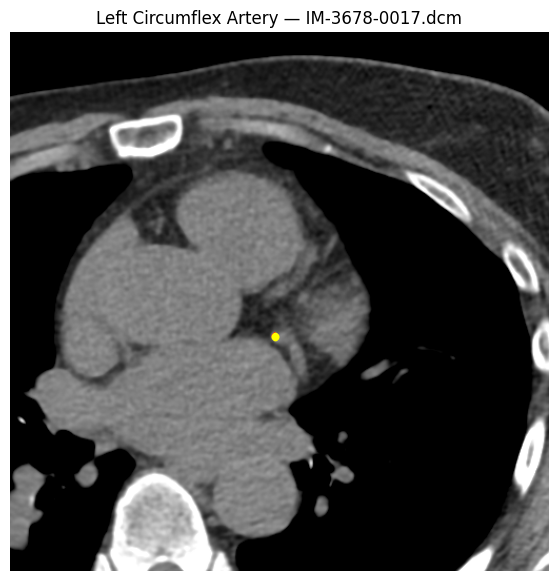

In [60]:
fig, ax = plt.subplots(figsize=(7, 7))

ax.imshow(matched_windowed, cmap="gray")

polygon = Polygon(
    points,
    closed=True,
    fill=False,
    edgecolor="red",
    linewidth=3
)

ax.add_patch(polygon)

ax.scatter(
    points[:, 0],
    points[:, 1],
    c="yellow",
    s=10
)

ax.set_title(
    f"{first_real_roi['name']} — "
    f"{best_match['filename']}"
)

ax.axis("off")
plt.savefig(
    "/content/drive/MyDrive/AI_Medical/COCA/figures/Calcium_ROI_Overlap.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [54]:
from matplotlib.path import Path

# Create a mask for pixels inside the polygon
height, width = matched_hu.shape
xx, yy = np.meshgrid(np.arange(width), np.arange(height))

pixel_coordinates = np.column_stack((xx.ravel(), yy.ravel()))

roi_mask = Path(points).contains_points(
    pixel_coordinates,
    radius=0.5
).reshape(height, width)

roi_hu_values = matched_hu[roi_mask]

print("Pixels inside ROI:", roi_hu_values.size)
print("Measured minimum HU:", roi_hu_values.min())
print("Measured mean HU:", roi_hu_values.mean())
print("Measured maximum HU:", roi_hu_values.max())

print("\nXML minimum HU:", target_entry["ROIs"][0]["Min"])
print("XML mean HU:", target_entry["ROIs"][0]["Mean"])
print("XML maximum HU:", target_entry["ROIs"][0]["Max"])

Pixels inside ROI: 2
Measured minimum HU: 135.0
Measured mean HU: 138.0
Measured maximum HU: 141.0

XML minimum HU: 135.0
XML mean HU: 138.0
XML maximum HU: 141.0
